In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here
import matplotlib.image as mpimg
import seaborn as sns

In [65]:
RESULTS_DATA_DIR = here() / "results"
PRED_GRAPHS_DIR = here() / "results" / "graphs" / "predictions_descriptive"

In [66]:
predictions = pd.read_csv(RESULTS_DATA_DIR/"predictions_benchmark.csv")

In [67]:
summary = pd.DataFrame(predictions.describe())
print(len(summary))

8


In [68]:
models = predictions.columns.tolist()[1:9]

### Histograms

In [69]:
def histogram(model):
    plt.figure(figsize=(8, 5))
    plt.hist(predictions[model], bins=300, color='skyblue', edgecolor='black', alpha=0.7)
    
    plt.title(f'{model} Predictions Distribution of Crime Rates per Municipality', fontsize=14, fontweight='bold')
    plt.xlabel('Crime Rate (per 100k)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(PRED_GRAPHS_DIR/'{model}_predictions_hist.png') 

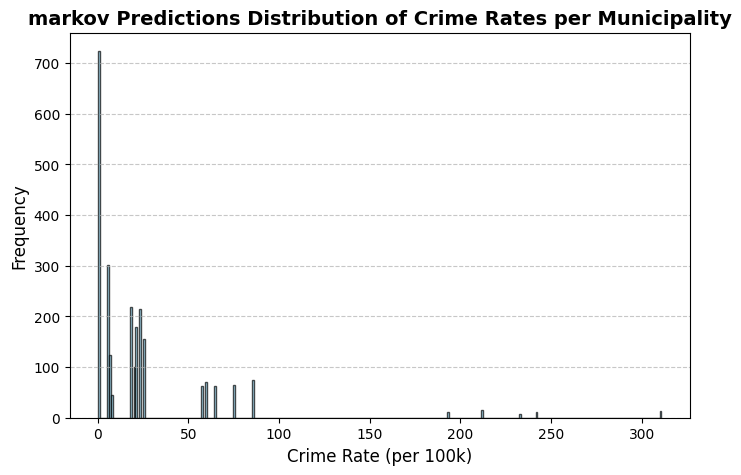

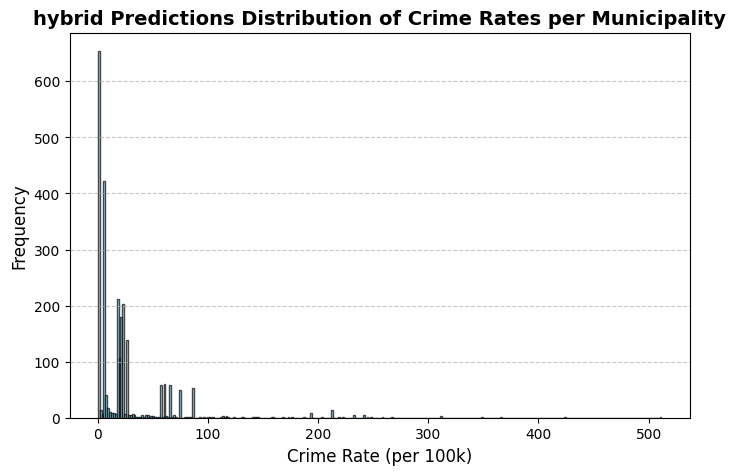

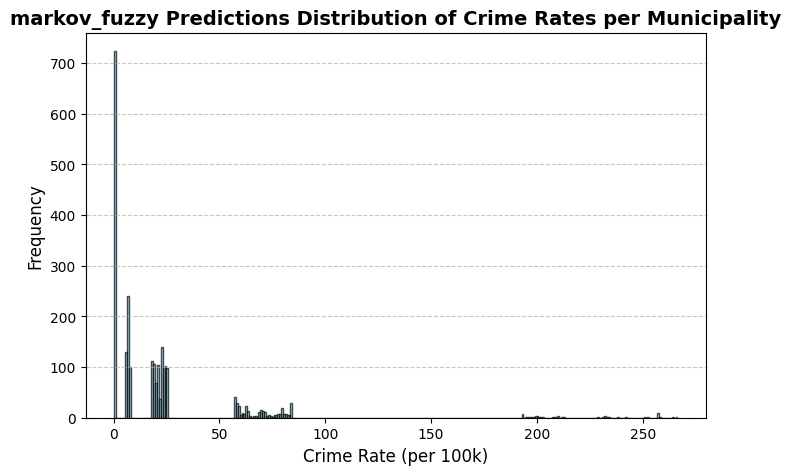

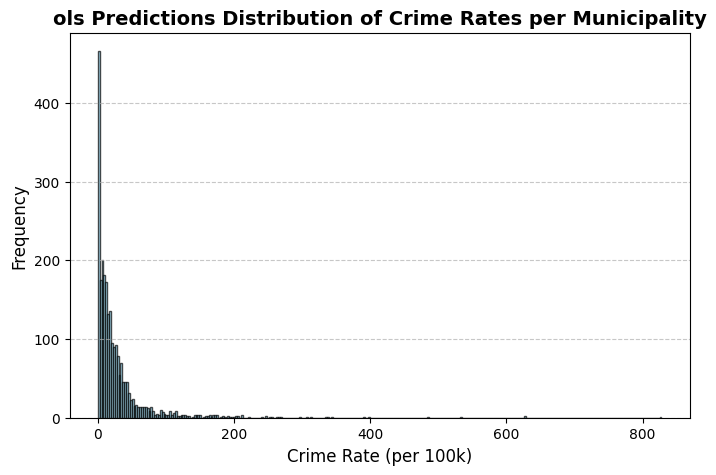

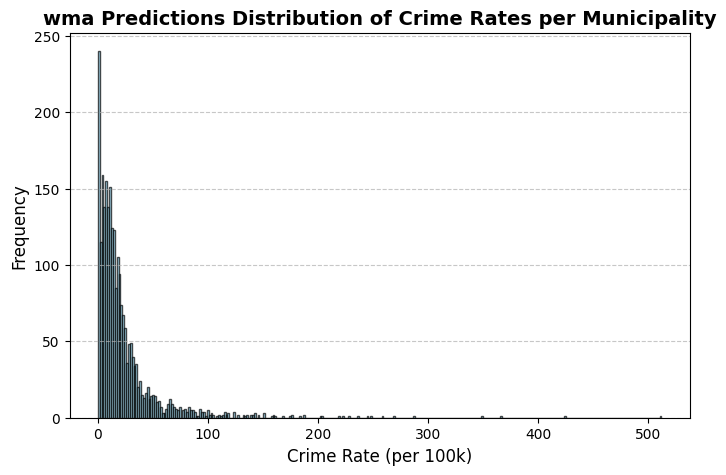

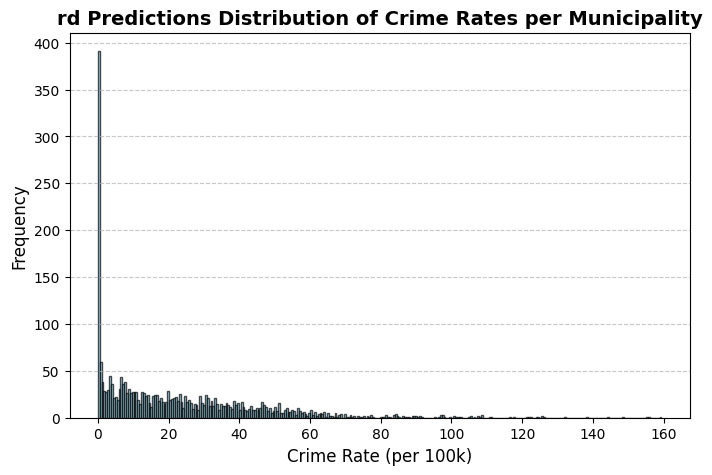

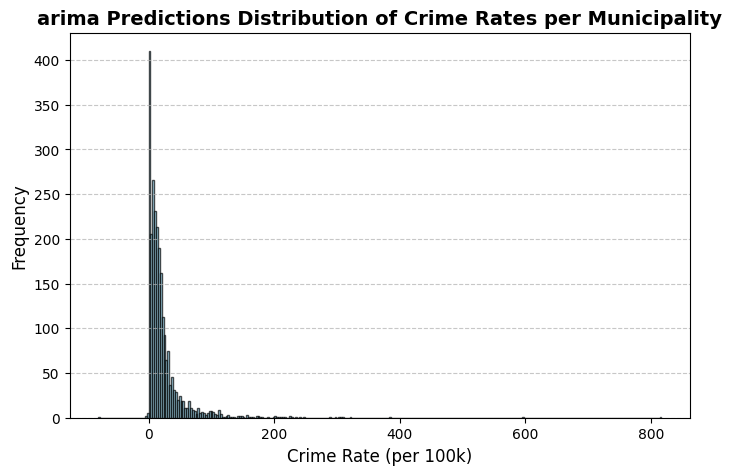

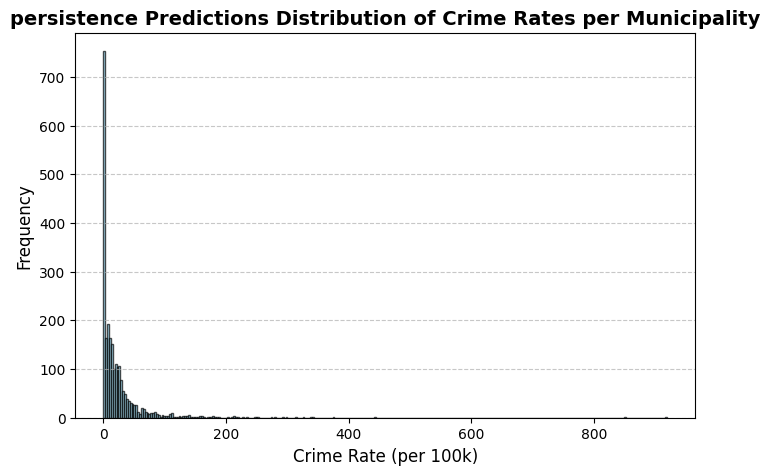

In [70]:
for model in models:
    histogram(model)

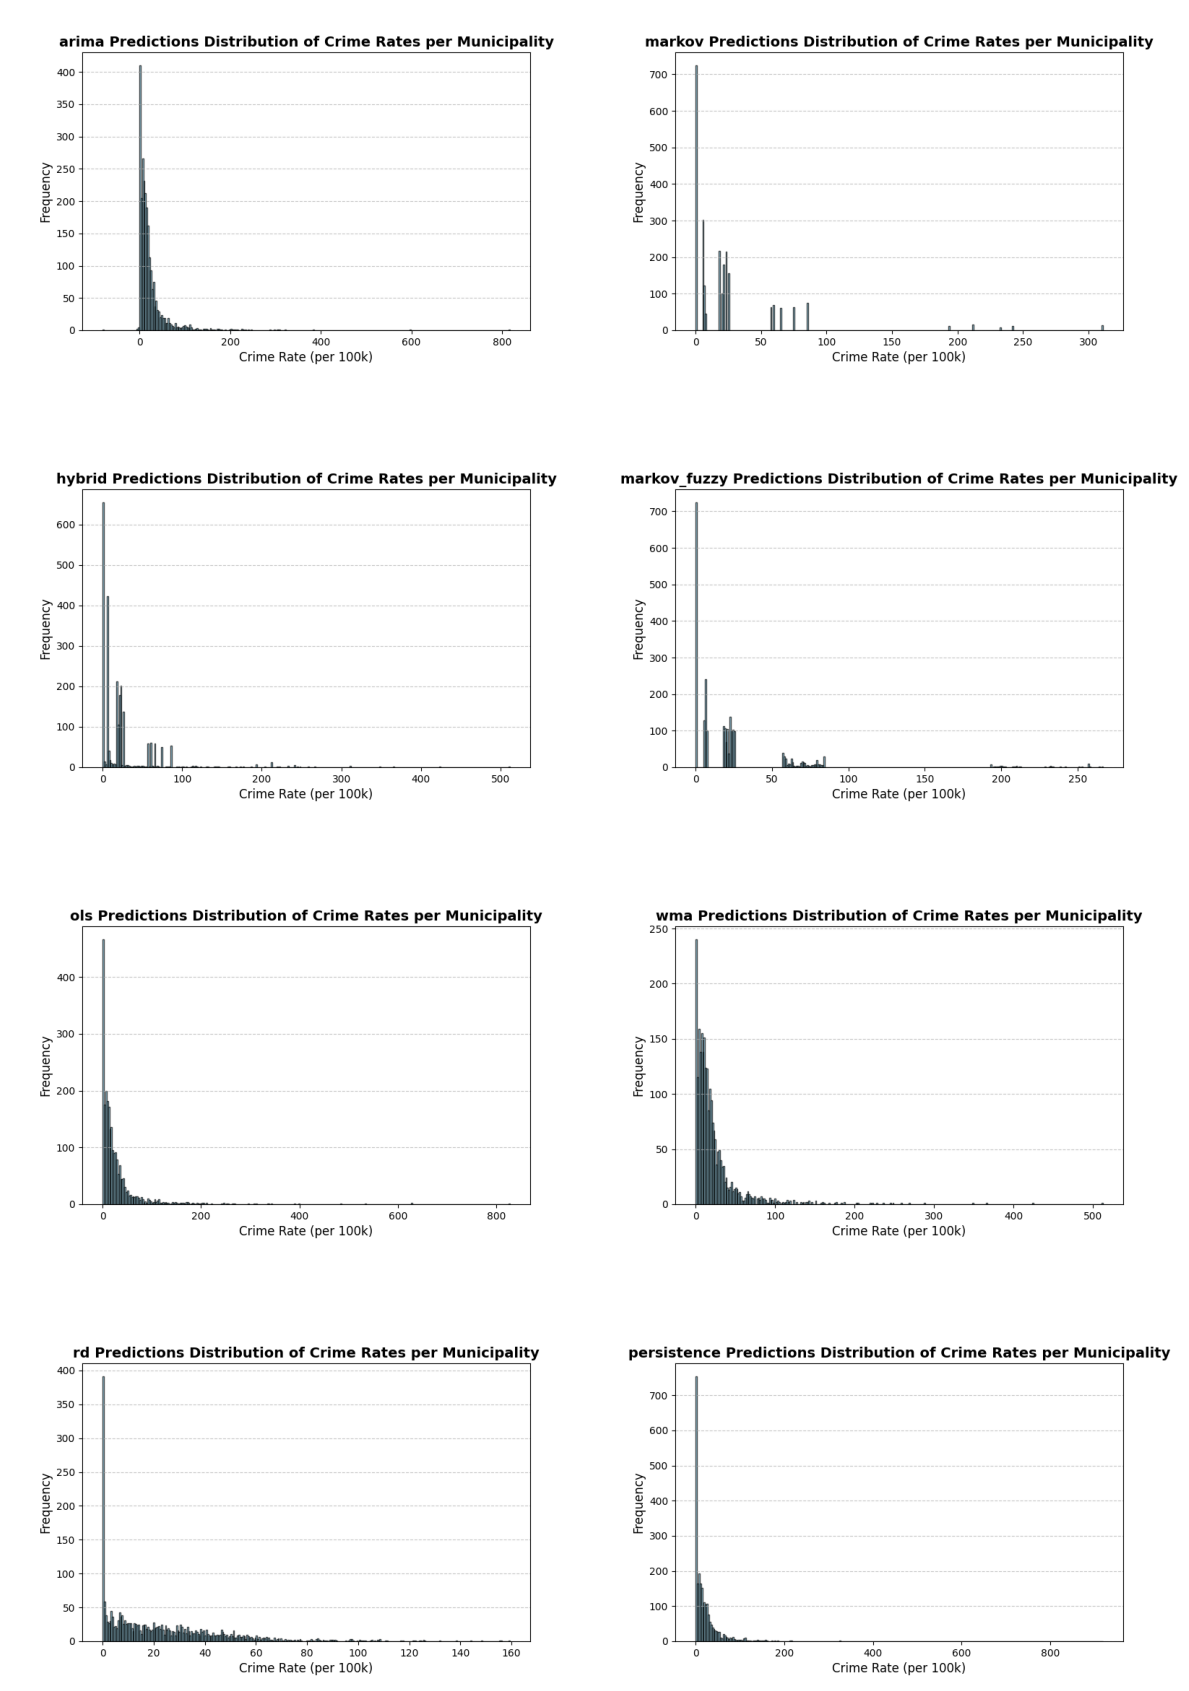

In [71]:
image_paths = [
    PRED_GRAPHS_DIR/'arima_predictions_hist.png', 
    PRED_GRAPHS_DIR/'markov_predictions_hist.png',
    PRED_GRAPHS_DIR/'hybrid_predictions_hist.png', 
    PRED_GRAPHS_DIR/'markov_fuzzy_predictions_hist.png',
    PRED_GRAPHS_DIR/'ols_predictions_hist.png', 
    PRED_GRAPHS_DIR/'wma_predictions_hist.png',
    PRED_GRAPHS_DIR/'rd_predictions_hist.png', 
    PRED_GRAPHS_DIR/'persistence_predictions_hist.png'
]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 18))
axes_flat = axes.flatten()

for i, img_path in enumerate(image_paths):
    ax = axes_flat[i]
    
    img = mpimg.imread(img_path)
    ax.imshow(img)
    
    ax.axis('off') 

plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/f'graphs/predictions_descriptive/predictions_histograms.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

### Boxplot

In [72]:
predictions = predictions.drop(columns="observed")

In [73]:
df_long = predictions.melt(
    id_vars=['CVEGEO'],          
    var_name='model',           
    value_name='crime_rate'            
)

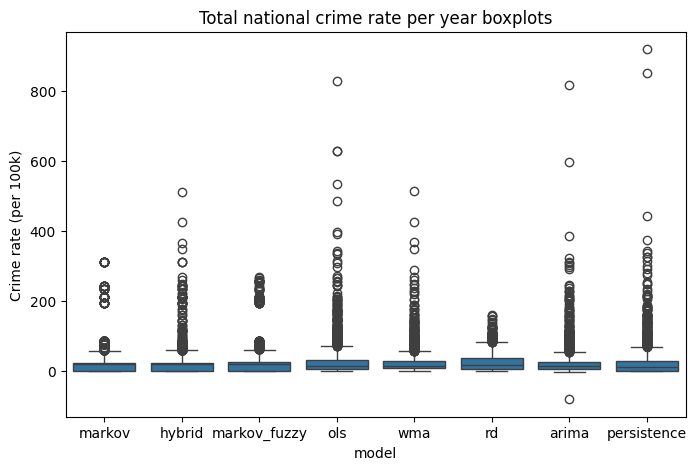

In [74]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_long, x='model', y='crime_rate')
plt.ylabel("Crime rate (per 100k)")
plt.title('Total national crime rate per year boxplots')
plt.savefig(PRED_GRAPHS_DIR/'predictions_boxplots.png') 
plt.show()
plt.close()